### HuffPost News Category Classification with DistilBERT

**Author:** Sung Song

This notebook implements a news category classification pipeline using the HuffPost News Category dataset. The workflow includes data preparation, label preprocessing, DistilBERT model training, and final evaluation using accuracy, macro F1, weighted F1, and a confusion matrix.

### Project Background and Data Exploration

I chose the HuffPost News Category dataset for this project because it was a good fit for a text classification task. The dataset contains about 200,000 news articles across 41 categories.

During exploratory data analysis, I found several issues that affected the modeling approach. The dataset had strong class imbalance, with categories such as POLITICS having many more examples than smaller categories such as EDUCATION. I also found missing short descriptions, duplicate headlines, near-duplicate articles, and overlapping category labels, such as PARENTS vs. PARENTING and STYLE vs. STYLE & BEAUTY.

Based on these findings, I treated the task as a multiclass classification problem and used macro F1 as the main evaluation metric. I also used a stratified train/validation/test split, class weights to reduce the impact of imbalance, and label merging for categories that were very similar or overlapping.

### Data Cleaning and Preprocessing

For preprocessing, I combined the headline and short_description fields into one text field. I also lowercased the text and removed extra whitespace so that small case or spacing differences would not affect the model input.

Rows with empty combined text were removed, and exact duplicate texts were also dropped to reduce data leakage across the train, validation, and test sets. I also merged several overlapping category labels found during the data exploration step, such as THE WORLDPOST into WORLDPOST, STYLE & BEAUTY into STYLE, PARENTS into PARENTING, HEALTHY LIVING into WELLNESS, and TASTE into FOOD & DRINK. After merging these labels, the number of categories was reduced from 41 to 34.

Finally, I converted the category names into numeric labels using LabelEncoder. The data was split into train, validation, and test sets using a stratified 80/10/10 split with random_state=42 for reproducibility.

### Text Representation and Class Imbalance

For the baseline models, I used Keras TextVectorization to convert the cleaned text into token sequences. I chose the maximum sequence length based on the 95th percentile of word counts so most articles would fit without making the inputs too long.

For DistilBERT, I used DistilBertTokenizerFast because it handles the tokenization, padding, truncation, and attention masks needed for the model.

Since the dataset was imbalanced, I used class weights so smaller categories would have more impact during training instead of being ignored by larger categories like POLITICS.

### Early Model Experiments

I tested three models using the same data split and evaluation metrics so I could compare them fairly.

| Model | Test Acc | Macro F1 | Params | Train Time |
|---|---|---|---|---|
| Baseline (Embedding → GAP → Dense) | 0.5575 | 0.4766 | 3.09M | ~0.6 min |
| Custom (BiGRU) | 0.5465 | 0.4714 | 3.14M | ~1.6 min |
| DistilBERT (frozen base + head) | 0.6511 | **0.5025** | ~67M | ~19.9 min |

The baseline model was simple and fast, but it probably lost useful word-order information. I expected the BiGRU to do better because it reads text in sequence, but it performed slightly worse than the baseline. The best model was DistilBERT, which had the highest accuracy and macro F1. The tradeoff was that it had many more parameters and took longer to train.

Based on these results, I decided to continue with DistilBERT and focus on improving the DistilBERT model.

### Loading the Dataset

In [1]:
# Install required libraries for data loading, modeling, and evaluation
!pip install -q datasets transformers tensorflow scikit-learn

# For loading HuffPost from Hugging Face
from datasets import load_dataset

# Use datasets.load_dataset() from Hugging Face to load HuffPost
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Setting the Random Seed

I set the random seed to 42 for Python, NumPy, and PyTorch so the data split and model training would be more consistent when rerunning the notebook.

Since I ran this notebook in Colab with a GPU, I also set the CUDA seed when available.

In [2]:
# Set all random seeds for reproducibility
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# using an A100 GPU in Colab, set the CUDA seed
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"all random seeds set to {SEED}")

all random seeds set to 42


### Checking Category Counts

Before cleaning the dataset, I checked how many articles were in each category. This helped show the original class distribution and made it clear that some categories had many more examples than others.

This step was useful for understanding the class imbalance before training the models.

In [3]:
# Category counts before any cleaning or label merging
# Shows the raw class distribution straight from the HuffPost dataset
from collections import Counter

raw_category_counts = Counter(huff_all["category"])
sorted_raw_counts = raw_category_counts.most_common()

print("number of categories before cleaning:", len(raw_category_counts))
print("total samples:", sum(raw_category_counts.values()))
print()
print("category counts (largest to smallest):")
for category_name, count in sorted_raw_counts:
    print(f"{category_name}: {count}")

number of categories before cleaning: 41
total samples: 200853

category counts (largest to smallest):
POLITICS: 32739
WELLNESS: 17827
ENTERTAINMENT: 16058
TRAVEL: 9887
STYLE & BEAUTY: 9649
PARENTING: 8677
HEALTHY LIVING: 6694
QUEER VOICES: 6314
FOOD & DRINK: 6226
BUSINESS: 5937
COMEDY: 5175
SPORTS: 4884
BLACK VOICES: 4528
HOME & LIVING: 4195
PARENTS: 3955
THE WORLDPOST: 3664
WEDDINGS: 3651
WOMEN: 3490
IMPACT: 3459
DIVORCE: 3426
CRIME: 3405
MEDIA: 2815
WEIRD NEWS: 2670
GREEN: 2622
WORLDPOST: 2579
RELIGION: 2556
STYLE: 2254
SCIENCE: 2178
WORLD NEWS: 2177
TASTE: 2096
TECH: 2082
MONEY: 1707
ARTS: 1509
FIFTY: 1401
GOOD NEWS: 1398
ARTS & CULTURE: 1339
ENVIRONMENT: 1323
COLLEGE: 1144
LATINO VOICES: 1129
CULTURE & ARTS: 1030
EDUCATION: 1004


### Plotting Category Counts

I plotted the category counts before cleaning or label merging to see the original class distribution. This helped show the class imbalance in the dataset and made it clear that some categories had many more examples than others.

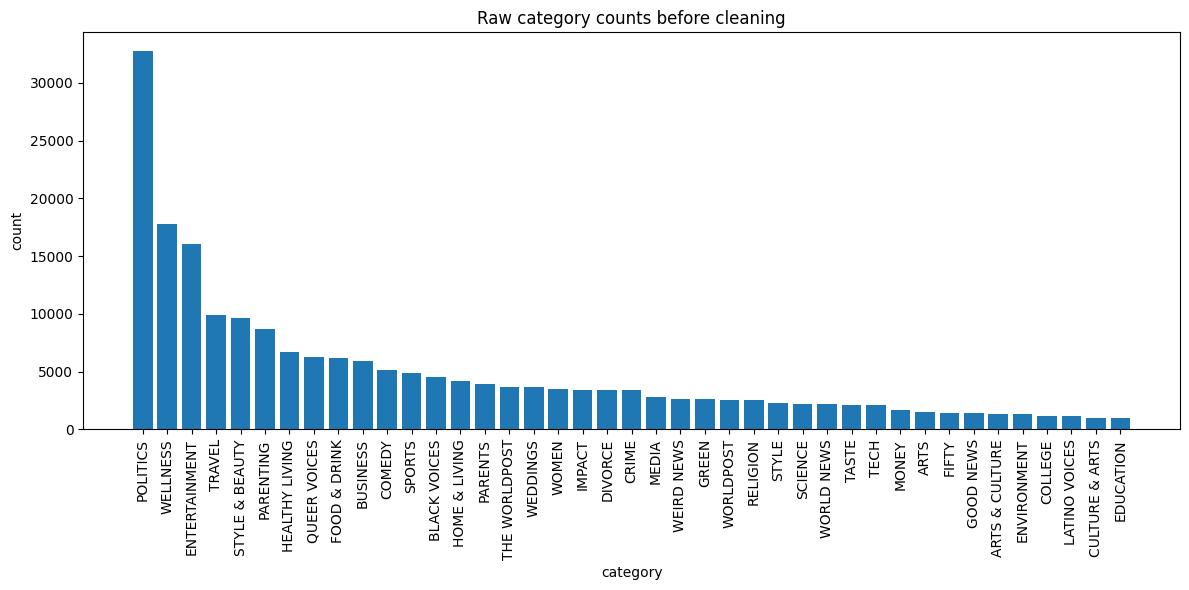

In [4]:
# Plot raw category counts before any cleaning or label merging
# Shows the original class distribution straight from the HuffPost dataset
import matplotlib.pyplot as plt
from collections import Counter

raw_category_counts = Counter(huff_all["category"])
sorted_raw_counts = raw_category_counts.most_common()

raw_category_names = [name for name, _ in sorted_raw_counts]
raw_category_totals = [count for _, count in sorted_raw_counts]

plt.figure(figsize=(12, 6))
plt.bar(raw_category_names, raw_category_totals)
plt.xticks(rotation=90)
plt.xlabel("category")
plt.ylabel("count")
plt.title("Raw category counts before cleaning")
plt.tight_layout()
plt.show()

### Inspecting the Dataset

I looked at the dataset size, column names, number of categories, and a few sample articles. This helped me understand what the data looked like before choosing the text fields and target label for the model.

In [5]:
# Display basic information (e.g., number of samples, feature names, example entries).

# started by checking the dataset size, columns, and a few sample articles
print("samples:", len(huff_all))
print("columns:", huff_all.column_names)
print("categories:", len(set(huff_all["category"])))

# print a few rows to inspect the data
for i in range(3):
    ex = huff_all[i]
    print(f"\n--- example {i+1} ---")
    print("category:", ex["category"])
    print("headline:", ex["headline"])
    print("short_description:", ex["short_description"])
    print("authors:", ex["authors"])
    print("link:", ex["link"])
    print("date:", ex["date"])

samples: 200853
columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
categories: 41

--- example 1 ---
category: CRIME
headline: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
short_description: She left her husband. He killed their children. Just another day in America.
authors: Melissa Jeltsen
link: https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89
date: 2018-05-26 00:00:00

--- example 2 ---
category: ENTERTAINMENT
headline: Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song
short_description: Of course it has a song.
authors: Andy McDonald
link: https://www.huffingtonpost.com/entry/will-smith-joins-diplo-and-nicky-jam-for-the-official-2018-world-cup-song_us_5b09726fe4b0fdb2aa541201
date: 2018-05-26 00:00:00

--- example 3 ---
category: ENTERTAINMENT
headline: Hugh Grant Marries For The First Time At Age 57
short_description: The actor and his longtime girlfriend

### Looking at the Text Fields

I checked a few headline and short_description examples before combining them. This helped me understand what the text looked like before using it as input for the model.

In [6]:
# before combining the text fields headline and short_description exanples

# two text fields before combined for a few real articles examples
for i in range(3):
    print(f"\n--- example {i+1} ---")
    print("headline:", huff_all[i]["headline"])
    print("short_description:", huff_all[i]["short_description"])


--- example 1 ---
headline: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
short_description: She left her husband. He killed their children. Just another day in America.

--- example 2 ---
headline: Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song
short_description: Of course it has a song.

--- example 3 ---
headline: Hugh Grant Marries For The First Time At Age 57
short_description: The actor and his longtime girlfriend Anna Eberstein tied the knot in a civil ceremony.


### Combining Headline and Description

I combined the headline and short_description fields into one text column for the model. I also checked a few examples to make sure the combined text looked correct.

In [7]:
# Apply cleaning and normalization
# Concatenate headline + summary for HuffPost

# convert Hugging Face dataset to a pandas DataFrame
df = huff_all.to_pandas()

# combined the headline and short_description into one text field
# fillna("") helps avoid if either field is missing issues
df["text"] = (
    df["headline"].fillna("") + " " + df["short_description"].fillna("")
).str.strip()

# Sanity check: make sure the number of rows stayed the same
print("total rows:", len(df))

# few combined examples
for i in range(3):
    print(f"\nexample {i+1}:")
    print(df["text"].iloc[i])

total rows: 200853

example 1:
There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV She left her husband. He killed their children. Just another day in America.

example 2:
Will Smith Joins Diplo And Nicky Jam For The 2018 World Cup's Official Song Of course it has a song.

example 3:
Hugh Grant Marries For The First Time At Age 57 The actor and his longtime girlfriend Anna Eberstein tied the knot in a civil ceremony.


### Cleaning the Text

I cleaned the combined text column by removing extra spaces and making the text lowercase. I also checked for blank rows and removed any rows that did not have usable text before modeling.

In [8]:
# Clean the combined text column before modeling
# Converts values to strings, removes extra spaces, and makes the text lowercase
df["text"] = df["text"].astype(str).str.strip().str.lower()

# Check whether any rows became empty after cleaning
empty_rows = df["text"] == ""
print("empty rows:", empty_rows.sum())

# Remove rows that do not have usable text
before = len(df)
df = df[~empty_rows].copy()

print("dropped rows:", before - len(df))
print("rows left:", len(df))

empty rows: 5
dropped rows: 5
rows left: 200848


### Removing Duplicate and Short Rows

I removed duplicate text rows and very short rows with fewer than 3 words. These rows were not useful for training and could make the results less reliable.

I did this before creating the train, validation, and test splits to reduce possible data leakage.

In [9]:
# Remove duplicate rows and extremely short text entries.

# remove duplicate text rows
before = len(df)
df = df.drop_duplicates(subset=["text"]).copy()
print("duplicate rows removed:", before - len(df))

# check for rows with very short text
short_rows = df["text"].apply(lambda x: len(x.split()) < 3)
print("rows with less than 3 words:", short_rows.sum())

# remove those short rows
before = len(df)
df = df[~short_rows].copy()

# confirm new count
print("short rows removed:", before - len(df))
print("rows left:", len(df))

duplicate rows removed: 491
rows with less than 3 words: 199
short rows removed: 199
rows left: 200158


### Merging Similar Labels

I merged categories that were very similar, such as STYLE & BEAUTY into STYLE and PARENTS into PARENTING. This reduced label overlap and made the classification task cleaner.

After merging these labels, the dataset had 34 categories.

In [10]:
# Merge closely related categories to reduce label overlap
label_merge_map = {
    "THE WORLDPOST": "WORLDPOST",
    "STYLE & BEAUTY": "STYLE",
    "PARENTS": "PARENTING",
    "HEALTHY LIVING": "WELLNESS",
    "TASTE": "FOOD & DRINK",
    "ARTS & CULTURE": "ARTS",
    "GREEN": "ENVIRONMENT",
}

# Apply the label merge and check the new number of categories
df["category"] = df["category"].replace(label_merge_map)

print("categories after merge:", df["category"].nunique())

categories after merge: 34


### Encoding the Labels

I converted the category names into numeric labels using LabelEncoder so the model could use them for training. I also checked the final number of classes after merging similar labels.

In [11]:
# Convert category names (strings): to numeric labels for the model
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["category"])

# Check the number of final classes
n_classes = len(encoder.classes_)
print("number of classes:", n_classes)

number of classes: 34


### Splitting the Data

I split the data into training, validation, and test sets. The test set was kept separate so it could be used only for the final evaluation.

I used stratified splitting so each set would have a similar mix of categories. The final split was about 80% training, 10% validation, and 10% test.

In [12]:
from sklearn.model_selection import train_test_split

# Create the input text and label arrays used for splitting
texts = df["text"].values
labels = df["label"].values

# Hold out the test set first so it stays separate until final evaluation
texts_left, texts_test, labels_left, labels_test = train_test_split(
    texts,
    labels,
    test_size=0.10,
    random_state=SEED,
    stratify=labels
)

# Use part of the remaining data for validation
# This keeps the final split close to 80% train, 10% validation, and 10% test
validation_ratio = 0.10 / 0.90

texts_train, texts_val, labels_train, labels_val = train_test_split(
    texts_left,
    labels_left,
    test_size=validation_ratio,
    random_state=SEED,
    stratify=labels_left
)

# Check the final dataset sizes
print("train size:", len(texts_train))
print("val size:", len(texts_val))
print("test size:", len(texts_test))

train size: 160126
val size: 20016
test size: 20016


### Checking Training Set Balance

I plotted the category counts in the training set after merging similar labels. This helped me check whether the training data was still imbalanced before modeling.

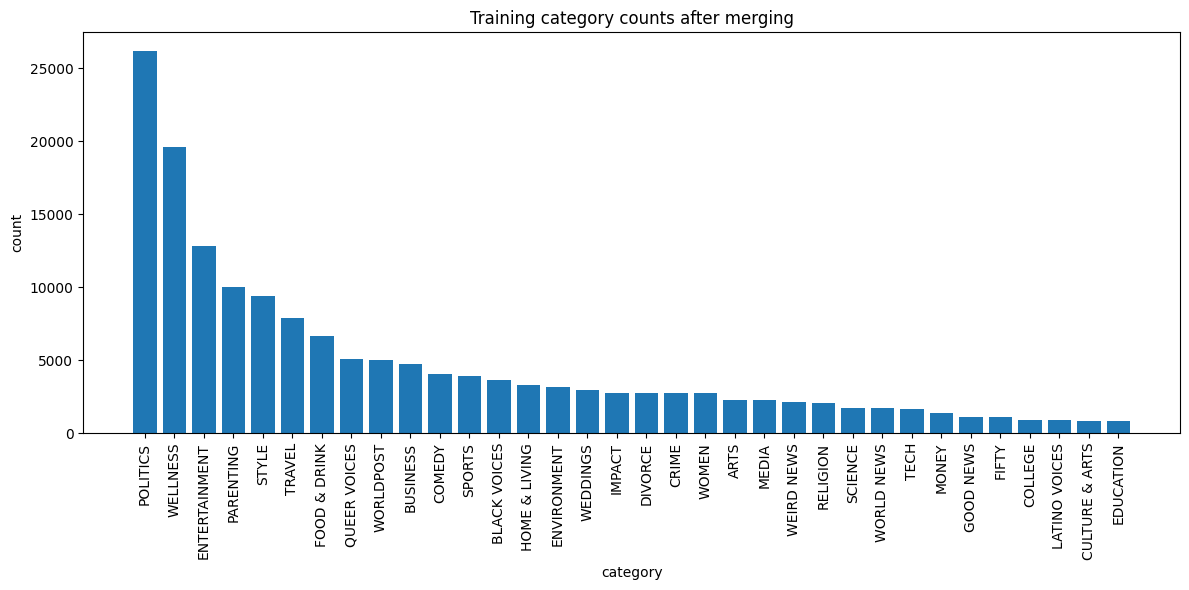

In [13]:
# Plot the training set categories to check the class balance
import matplotlib.pyplot as plt
from collections import Counter

train_category_counts = Counter(labels_train)
sorted_category_counts = train_category_counts.most_common()

category_names = [encoder.classes_[label_id] for label_id, _ in sorted_category_counts]
category_totals = [count for _, count in sorted_category_counts]

plt.figure(figsize=(12, 6))
plt.bar(category_names, category_totals)
plt.xticks(rotation=90)
plt.xlabel("category")
plt.ylabel("count")
plt.title("Training category counts after merging")
plt.tight_layout()
plt.show()

### Final Category Counts

I checked the category counts again after cleaning and label merging. This showed the final class distribution that would be used for modeling.

In [14]:
# Category counts after cleaning and label merging
# Shows the final class distribution that goes into the model
from collections import Counter

cleaned_category_counts = Counter(df["category"])
sorted_cleaned_counts = cleaned_category_counts.most_common()

print("number of categories after cleaning:", len(cleaned_category_counts))
print("total samples:", sum(cleaned_category_counts.values()))
print()
print("category counts (largest to smallest):")
for category_name, count in sorted_cleaned_counts:
    print(f"{category_name}: {count}")

number of categories after cleaning: 34
total samples: 200158

category counts (largest to smallest):
POLITICS: 32700
WELLNESS: 24490
ENTERTAINMENT: 16048
PARENTING: 12546
STYLE: 11757
TRAVEL: 9877
FOOD & DRINK: 8315
QUEER VOICES: 6308
WORLDPOST: 6232
BUSINESS: 5925
COMEDY: 5089
SPORTS: 4879
BLACK VOICES: 4521
HOME & LIVING: 4160
ENVIRONMENT: 3937
WEDDINGS: 3651
IMPACT: 3454
DIVORCE: 3422
CRIME: 3400
WOMEN: 3397
ARTS: 2842
MEDIA: 2811
WEIRD NEWS: 2667
RELIGION: 2545
SCIENCE: 2178
WORLD NEWS: 2176
TECH: 2033
MONEY: 1706
GOOD NEWS: 1396
FIFTY: 1392
COLLEGE: 1142
LATINO VOICES: 1129
CULTURE & ARTS: 1029
EDUCATION: 1004


### Class Weights

I created class weights from the training labels because some categories had many fewer articles than others. This helped give smaller categories more importance during training.

I also printed a few example weights to check that the class balancing worked.

In [15]:
# Create class weights so smaller categories get more attention during training
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_ids = np.unique(labels_train)

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=labels_train
)

class_weights = dict(zip(class_ids, balanced_weights))

# Print a few weights to check how the balancing looks
print("example weights:")
for class_id in class_ids[:5]:
    print(encoder.classes_[class_id], "=", round(class_weights[class_id], 3))

example weights:
ARTS = 2.071
BLACK VOICES = 1.302
BUSINESS = 0.994
COLLEGE = 5.153
COMEDY = 1.157


### Preparing Text for DistilBERT

I tokenized the text using the DistilBERT tokenizer so it could be used by the model. Then I converted the train, validation, and test sets into PyTorch datasets and dataloaders.

I also checked one batch to make sure the input shapes looked correct before training.

In [16]:
# Tokenize text with DistilBERT and build PyTorch DataLoaders
import torch
from transformers import DistilBertTokenizerFast
from torch.utils.data import DataLoader, TensorDataset

# Use the tokenizer that matches the pretrained DistilBERT model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

# 128 tokens is enough for most article headlines + descriptions
MAX_LEN = 128

def tokenize_texts(text_list):
    return tokenizer(
        list(text_list),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

# Tokenize each split separately
train_tokens = tokenize_texts(texts_train)
val_tokens = tokenize_texts(texts_val)
test_tokens = tokenize_texts(texts_test)

# Combine tokenized text and labels into PyTorch datasets
train_ds = TensorDataset(
    train_tokens["input_ids"],
    train_tokens["attention_mask"],
    torch.tensor(labels_train, dtype=torch.long)
)

val_ds = TensorDataset(
    val_tokens["input_ids"],
    val_tokens["attention_mask"],
    torch.tensor(labels_val, dtype=torch.long)
)

test_ds = TensorDataset(
    test_tokens["input_ids"],
    test_tokens["attention_mask"],
    torch.tensor(labels_test, dtype=torch.long)
)

# Build DataLoaders for training and evaluation
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# Quick shape check for one training batch
for input_ids, attention_mask, batch_labels in train_loader:
    print("input_ids shape:", input_ids.shape)
    print("attention_mask shape:", attention_mask.shape)
    print("labels shape:", batch_labels.shape)
    break

input_ids shape: torch.Size([32, 128])
attention_mask shape: torch.Size([32, 128])
labels shape: torch.Size([32])


## Final Model Selection

I chose distilbert-base-uncased because it performed best in the earlier model comparison. The frozen DistilBERT model had the highest test accuracy at 0.6511 and the best macro F1 at 0.5025. The baseline model had a lower macro F1 of 0.4766.

For the final model, I used partial fine-tuning. I froze the lower 4 transformer layers and trained the upper 2 layers plus the classification head. I chose this because the lower layers could keep the pretrained language knowledge, while the upper layers could adjust more to the HuffPost category task.

### Loading the DistilBERT Model

I loaded distilbert-base-uncased for the category classification model. I froze the embedding layer and lower transformer layers so only the upper layers and classification head would train.

This helped keep training more manageable while still letting the model adjust to the HuffPost dataset.

In [17]:
# Load DistilBERT for classification and freeze some lower layers
from transformers import DistilBertForSequenceClassification
import torch

# Use the number of categories from the LabelEncoder step
num_labels = n_classes

# DistilBERT has 6 transformer layers, so this freezes layers 0-3
frozen_layer_count = 4

# Use GPU in Colab if it is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Load DistilBERT with a new classification layer for this project
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
).to(device)

# Freeze the embedding layer first
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False

# Freeze the lower transformer layers and leave the top layers trainable
for layer_num in range(frozen_layer_count):
    for param in model.distilbert.transformer.layer[layer_num].parameters():
        param.requires_grad = False

# Check how many parameters will actually update during training
total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

print(f"total parameters: {total_params:,}")
print(f"trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.1f}%)")

device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total parameters: 66,979,618
trainable parameters: 14,792,482 (22.1%)


### Training Settings

I set the main training settings for the final DistilBERT model, including the learning rate, weight decay, number of epochs, batch size, dropout, and early stopping patience.

I printed the settings so they would be easy to check before training.

In [18]:
# Main training settings for the final DistilBERT model

learning_rate = 2e-5        # common starting point for fine-tuning transformers
weight_decay = 0.01         # small regularization to reduce overfitting
num_epochs = 10             # early stopping may stop training before this
patience = 3                # stop if validation loss does not improve
dropout_rate = 0.1          # default DistilBERT dropout
batch_size = 32             # same batch size used in the DataLoaders
warmup_ratio = 0.1          # use 10% of training steps for warmup

# Print the settings so they are easy to reference later
print(f"learning_rate:      {learning_rate}")
print(f"weight_decay:       {weight_decay}")
print(f"num_epochs:         {num_epochs}")
print(f"patience:           {patience}")
print(f"dropout_rate:       {dropout_rate}")
print(f"batch_size:         {batch_size}")
print(f"warmup_ratio:       {warmup_ratio}")
print(f"num_labels:         {num_labels}")
print(f"frozen layers:      {frozen_layer_count}")

learning_rate:      2e-05
weight_decay:       0.01
num_epochs:         10
patience:           3
dropout_rate:       0.1
batch_size:         32
warmup_ratio:       0.1
num_labels:         34
frozen layers:      4


### Optimizer and Loss

I used AdamW as the optimizer because it is commonly used for fine-tuning transformer models. I also used a warmup schedule so the learning rate starts lower before reaching the main rate.

For the loss function, I used cross-entropy loss with class weights. This helped smaller categories matter more during training since the dataset was not evenly balanced.

In [19]:
# Set up the optimizer, learning rate schedule, and weighted loss
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

# AdamW is commonly used for transformer fine-tuning
optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

# Total training steps are based on epochs and number of training batches
total_training_steps = num_epochs * len(train_loader)
warmup_steps = int(warmup_ratio * total_training_steps)

# Warmup starts the learning rate lower before reaching the main rate
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

# Convert the class weights into a tensor for CrossEntropyLoss
# The weights help smaller classes count more during training
class_weight_tensor = torch.tensor(
    [class_weights[i] for i in range(num_labels)],
    dtype=torch.float
).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weight_tensor)

print("optimizer: AdamW")
print("learning rate:", learning_rate)
print("weight decay:", weight_decay)
print("total train steps:", total_training_steps)
print("warmup steps:", warmup_steps)
print("loss: CrossEntropyLoss with balanced class weights")

optimizer: AdamW
learning rate: 2e-05
weight decay: 0.01
total train steps: 50040
warmup steps: 5004
loss: CrossEntropyLoss with balanced class weights


### Early Stopping and Checkpointing

I used early stopping to stop training when the validation loss stopped improving. I also saved the best model weights during training so the final model would use the best validation result, not just the last epoch.

The learning rate scheduler was already set up in the optimizer section, so this cell focuses on early stopping and saving the best weights.

In [20]:
# Early stopping helper for validation loss
# Saves the best model weights and stops after several non-improving epochs

class EarlyStopper:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_loss = float("inf")
        self.epochs_no_improve = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss, model):
        # Save model weights when validation loss improves
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.epochs_no_improve = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # Count epochs where validation loss does not improve
        else:
            self.epochs_no_improve += 1
            if self.epochs_no_improve >= self.patience:
                self.should_stop = True


# Create the early stopper using the selected patience value
stopper = EarlyStopper(patience=patience)

print(f"early stopping configured: patience = {patience} epochs on val_loss")
print("best model weights are saved inside the EarlyStopper class")

early stopping configured: patience = 3 epochs on val_loss
best model weights are saved inside the EarlyStopper class


### Training DistilBERT

I trained the DistilBERT model using the training set and checked performance on the validation set after each epoch. The training loop tracked loss and accuracy, updated the learning rate scheduler, and used early stopping when the validation loss stopped improving.

After training, I loaded the best saved model weights before moving on to final evaluation.

In [21]:
# Training loop with validation tracking and early stopping
import time

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

start_time = time.time()

for epoch in range(num_epochs):
    # ----- training -----
    model.train()

    train_loss_total = 0
    train_correct = 0
    train_total = 0

    for input_ids, attention_mask, batch_labels in train_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = loss_fn(logits, batch_labels)
        loss.backward()

        optimizer.step()
        scheduler.step()

        train_loss_total += loss.item() * batch_labels.size(0)
        predictions = torch.argmax(logits, dim=1)

        train_correct += (predictions == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    train_loss = train_loss_total / train_total
    train_acc = train_correct / train_total

    # ----- validation -----
    model.eval()

    val_loss_total = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for input_ids, attention_mask, batch_labels in val_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = loss_fn(logits, batch_labels)

            val_loss_total += loss.item() * batch_labels.size(0)
            predictions = torch.argmax(logits, dim=1)

            val_correct += (predictions == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    # Save results for later plots
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"epoch {epoch + 1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    # Stop training if validation loss stops improving
    stopper.step(val_loss, model)

    if stopper.should_stop:
        print(f"early stopping triggered after epoch {epoch + 1}")
        break

# Restore the best validation-loss model
if stopper.best_state is not None:
    model.load_state_dict(stopper.best_state)
    print("best model weights restored")

elapsed_time = time.time() - start_time
print(f"training time: {elapsed_time / 60:.2f} minutes")

epoch 1/10 | train_loss=2.1918, train_acc=0.4720 | val_loss=1.3786, val_acc=0.6008
epoch 2/10 | train_loss=1.3038, train_acc=0.6097 | val_loss=1.2260, val_acc=0.6288
epoch 3/10 | train_loss=1.1447, train_acc=0.6392 | val_loss=1.1856, val_acc=0.6391
epoch 4/10 | train_loss=1.0297, train_acc=0.6621 | val_loss=1.1585, val_acc=0.6451
epoch 5/10 | train_loss=0.9346, train_acc=0.6820 | val_loss=1.1556, val_acc=0.6538
epoch 6/10 | train_loss=0.8509, train_acc=0.6971 | val_loss=1.1606, val_acc=0.6617
epoch 7/10 | train_loss=0.7786, train_acc=0.7110 | val_loss=1.1737, val_acc=0.6688
epoch 8/10 | train_loss=0.7209, train_acc=0.7250 | val_loss=1.1978, val_acc=0.6639
early stopping triggered after epoch 8
best model weights restored
training time: 29.08 minutes


### Evaluation Strategy

I used the validation set during training to check validation loss and accuracy after each epoch. It also helped with early stopping and saving the best model weights.

The test set was kept separate and was only used for the final evaluation. This made the final results a better estimate of how the model would perform on new articles.

Since the dataset was imbalanced, I did not rely only on accuracy. I used macro F1 as the main metric because it treats each category more equally. I also used weighted F1, accuracy, per-class precision/recall, and a confusion matrix to better understand where the model did well and where it struggled.

### Test Set Predictions

I ran the trained model on the separate test set and saved the predicted labels. I also kept the true labels so I could calculate accuracy, F1 scores, the classification report, and the confusion matrix.

In [22]:
# The test set is only used here for final evaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

model.eval()

test_predictions = []
test_true_labels = []

with torch.no_grad():
    for input_ids, attention_mask, batch_labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        batch_predictions = outputs.logits.argmax(dim=1).cpu().numpy()

        test_predictions.extend(batch_predictions)
        test_true_labels.extend(batch_labels.numpy())

test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)

print(f"test set predictions complete: {len(test_predictions)} samples")

test set predictions complete: 20016 samples


### Training Curves

I plotted the training and validation loss and accuracy for each epoch. This helped me see how the model changed during training and whether it showed signs of overfitting.

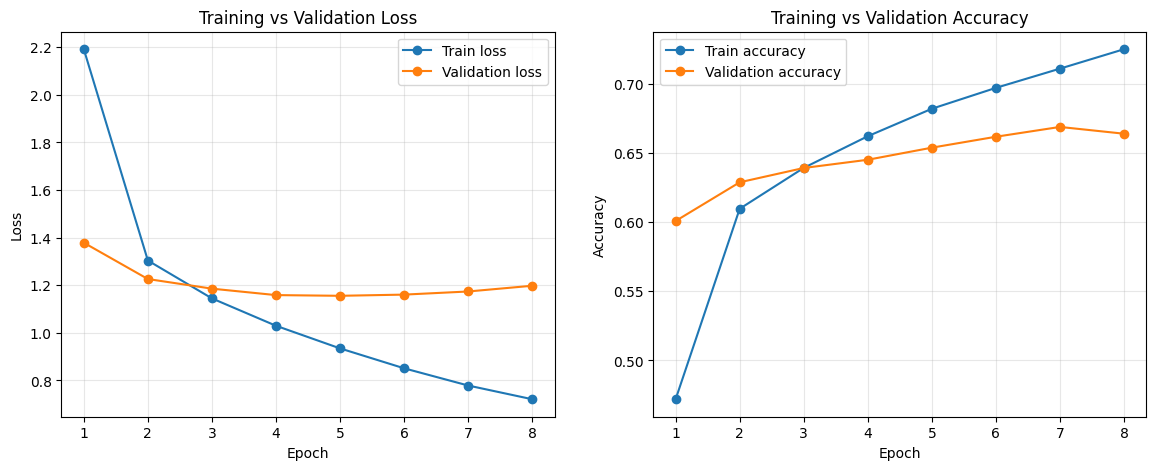

In [23]:
# Plot loss and accuracy to check how training changed over epochs
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training and validation loss
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training and validation accuracy
axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train accuracy")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

### Final Test Evaluation and Confusion Matrix

I evaluated the final model on the test set using accuracy, macro F1, weighted F1, and a classification report. I also plotted a confusion matrix to see which categories the model predicted correctly and which ones it confused.

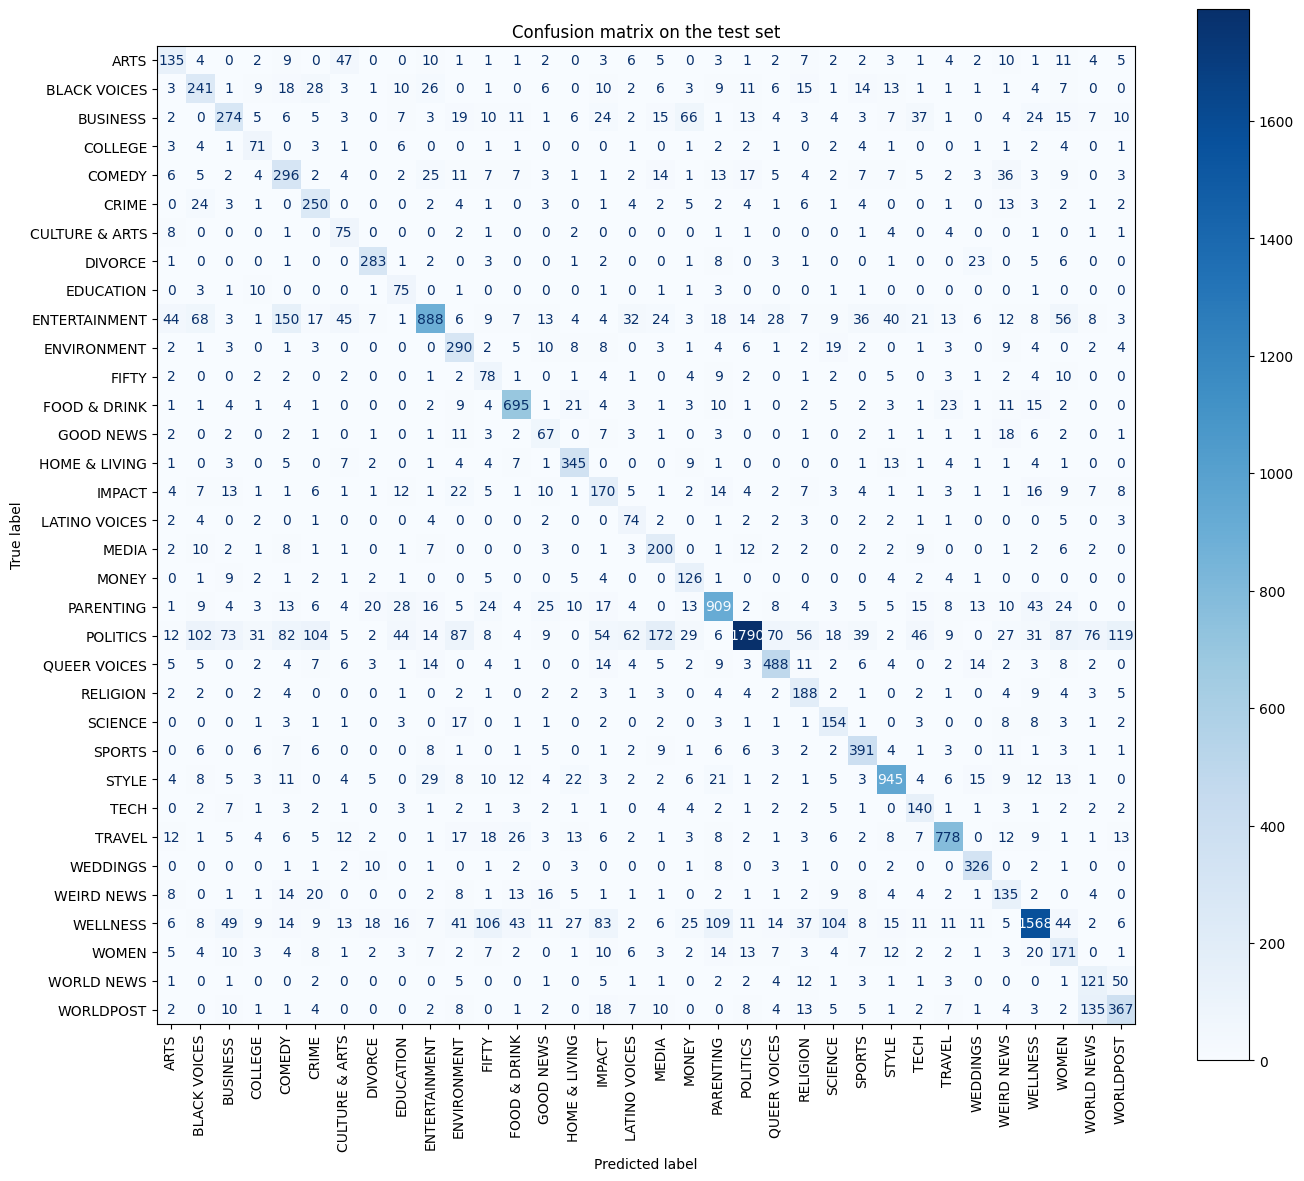

FINAL TEST PERFORMANCE
Test accuracy:    0.6547
Test macro F1:    0.5845
Test weighted F1: 0.6676

Per-class precision, recall, F1:
--------------------------------------------------
                precision    recall  f1-score   support

          ARTS     0.4891    0.4754    0.4821       284
  BLACK VOICES     0.4635    0.5332    0.4959       452
      BUSINESS     0.5638    0.4628    0.5083       592
       COLLEGE     0.3966    0.6228    0.4846       114
        COMEDY     0.4405    0.5815    0.5013       509
         CRIME     0.5051    0.7353    0.5988       340
CULTURE & ARTS     0.3138    0.7282    0.4386       103
       DIVORCE     0.7861    0.8275    0.8063       342
     EDUCATION     0.3488    0.7500    0.4762       100
 ENTERTAINMENT     0.8260    0.5533    0.6627      1605
   ENVIRONMENT     0.4957    0.7360    0.5924       394
         FIFTY     0.2468    0.5612    0.3429       139
  FOOD & DRINK     0.8167    0.8363    0.8264       831
     GOOD NEWS     0.3300    0.4

In [27]:
# Plot the test set confusion matrix
# Final test performance printout
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

# Make sure all 34 classes are included in the report
class_ids = np.arange(len(encoder.classes_))

# Plot the confusion matrix as a heatmap
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(test_true_labels, test_predictions, labels=class_ids)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    labels=class_ids,
    zero_division=0
)
test_weighted_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    labels=class_ids,
    zero_division=0
)

print("=" * 50)
print("FINAL TEST PERFORMANCE")
print("=" * 50)
print(f"Test accuracy:    {test_accuracy:.4f}")
print(f"Test macro F1:    {test_macro_f1:.4f}")
print(f"Test weighted F1: {test_weighted_f1:.4f}")
print()
print("Per-class precision, recall, F1:")
print("-" * 50)

print(
    classification_report(
        test_true_labels,
        test_predictions,
        labels=class_ids,
        target_names=encoder.classes_,
        digits=4,
        zero_division=0
    )
)

### Final Model Scores

I calculated the final test accuracy, macro F1, and weighted F1 scores. I also printed the classification report so I could check precision, recall, and F1 for each category.

In [25]:
# Final test scores for the model
# The report also shows precision, recall, and F1 for each category

from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

final_class_ids = np.arange(len(encoder.classes_))

test_accuracy = accuracy_score(test_true_labels, test_predictions)

test_macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    labels=final_class_ids,
    zero_division=0
)

test_weighted_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    labels=final_class_ids,
    zero_division=0
)

print("=" * 50)
print("FINAL TEST PERFORMANCE")
print("=" * 50)
print(f"Test accuracy:    {test_accuracy:.4f}")
print(f"Test macro F1:    {test_macro_f1:.4f}")
print(f"Test weighted F1: {test_weighted_f1:.4f}")
print()
print("Per-class precision, recall, and F1:")
print("-" * 50)

print(classification_report(
    test_true_labels,
    test_predictions,
    labels=final_class_ids,
    target_names=encoder.classes_,
    digits=4,
    zero_division=0
))

FINAL TEST PERFORMANCE
Test accuracy:    0.6547
Test macro F1:    0.5845
Test weighted F1: 0.6676

Per-class precision, recall, and F1:
--------------------------------------------------
                precision    recall  f1-score   support

          ARTS     0.4891    0.4754    0.4821       284
  BLACK VOICES     0.4635    0.5332    0.4959       452
      BUSINESS     0.5638    0.4628    0.5083       592
       COLLEGE     0.3966    0.6228    0.4846       114
        COMEDY     0.4405    0.5815    0.5013       509
         CRIME     0.5051    0.7353    0.5988       340
CULTURE & ARTS     0.3138    0.7282    0.4386       103
       DIVORCE     0.7861    0.8275    0.8063       342
     EDUCATION     0.3488    0.7500    0.4762       100
 ENTERTAINMENT     0.8260    0.5533    0.6627      1605
   ENVIRONMENT     0.4957    0.7360    0.5924       394
         FIFTY     0.2468    0.5612    0.3429       139
  FOOD & DRINK     0.8167    0.8363    0.8264       831
     GOOD NEWS     0.3300   

### Detailed Test Metrics

I printed the final test metrics and the full classification report. This helped me check the overall model performance as well as precision, recall, and F1 score for each category.



In [26]:
# Final test metrics and per-class report
# This gives the main test scores plus precision, recall, F1, and support for each category
# clean printout

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np

# Make sure all final categories are included in the same order as the encoder
final_class_ids = np.arange(len(encoder.classes_))

# Main test scores
test_accuracy = accuracy_score(test_true_labels, test_predictions)

test_macro_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="macro",
    labels=final_class_ids,
    zero_division=0
)

test_macro_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="macro",
    labels=final_class_ids,
    zero_division=0
)

test_macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    labels=final_class_ids,
    zero_division=0
)

test_weighted_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    labels=final_class_ids,
    zero_division=0
)

test_weighted_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    labels=final_class_ids,
    zero_division=0
)

test_weighted_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    labels=final_class_ids,
    zero_division=0
)

# Clean summary printout
print("=" * 50)
print("FINAL TEST PERFORMANCE")
print("=" * 50)
print(f"Test accuracy:           {test_accuracy:.4f}")
print()
print("Macro averages (each class equal weight):")
print(f"  Macro precision:       {test_macro_precision:.4f}")
print(f"  Macro recall:          {test_macro_recall:.4f}")
print(f"  Macro F1:              {test_macro_f1:.4f}")
print()
print("Weighted averages (by class size):")
print(f"  Weighted precision:    {test_weighted_precision:.4f}")
print(f"  Weighted recall:       {test_weighted_recall:.4f}")
print(f"  Weighted F1:           {test_weighted_f1:.4f}")
print("=" * 50)
print()

# Full per-class table
print("PER-CLASS PRECISION, RECALL, F1")
print("-" * 50)

print(classification_report(
    test_true_labels,
    test_predictions,
    labels=final_class_ids,
    target_names=encoder.classes_,
    digits=4,
    zero_division=0
))

FINAL TEST PERFORMANCE
Test accuracy:           0.6547

Macro averages (each class equal weight):
  Macro precision:       0.5485
  Macro recall:          0.6637
  Macro F1:              0.5845

Weighted averages (by class size):
  Weighted precision:    0.7177
  Weighted recall:       0.6547
  Weighted F1:           0.6676

PER-CLASS PRECISION, RECALL, F1
--------------------------------------------------
                precision    recall  f1-score   support

          ARTS     0.4891    0.4754    0.4821       284
  BLACK VOICES     0.4635    0.5332    0.4959       452
      BUSINESS     0.5638    0.4628    0.5083       592
       COLLEGE     0.3966    0.6228    0.4846       114
        COMEDY     0.4405    0.5815    0.5013       509
         CRIME     0.5051    0.7353    0.5988       340
CULTURE & ARTS     0.3138    0.7282    0.4386       103
       DIVORCE     0.7861    0.8275    0.8063       342
     EDUCATION     0.3488    0.7500    0.4762       100
 ENTERTAINMENT     0.8260    